# RTDA — `aie_batch` reference and analysis

**The question this notebook exists to answer:** `aie_batch` runs ~27× faster than `aieml/`.
Is it still computing the RTDA physics model correctly?

To answer that you need something to compare against, and that turns out to be the hard part:

- **A reference you wrote yourself can be wrong in the same way the design is wrong.** That has
  already happened twice on this project — plain ReLU instead of leaky, and a missing ReLU after
  each solver's `dense3`. Both times a self-consistent Keras reference reported MSE 6e-13 while
  the design was wrong. Self-consistency proves nothing.
- **Several references exist and they legitimately disagree**, because they use different
  averaging conventions and different roll behaviour. Compare against the wrong one and you see a
  difference that looks like a hardware bug but is pure convention.

So the reference here is the **original ONNX model from the physics side** — something neither the
AIE design nor its numpy golden was derived from.

## What each section does, and why

| § | | why it is there |
|---|---|---|
| 1 | Pin the model, verify the weight chain | proves ONNX == `model/weights_fp32` == what silicon actually runs |
| 2 | 50-track gate | before trusting the ONNX on 50,000 tracks, check it where we have known-good data |
| 3 | Build the 50k reference | the blank reference, on the exact stimulus the board runs |
| 4 | Load the `aie_batch` simulations | x86 and cycle-accurate, unpacked from slots back to events |
| 5 | Warm-up | separates *convention* differences from *arithmetic* differences |
| 6 | Hardware | same reference, all 1000 events, once board data exists |
| 7 | Performance | the measured hardware timing and its fit |
| 8 | Precision | why the residual can never be zero, and where it comes from |

**Environment.** Needs `numpy`, `onnx`, `onnxruntime`, `matplotlib` — nothing project-specific,
no aie4ml. `envaie2` has onnx but not onnxruntime/matplotlib:

    /home/synthara/miniforge3/envs/envaie2/bin/pip install onnxruntime matplotlib

`o2v` (`/home/synthara/.conda/envs/o2v`) already has all four if you prefer not to touch envaie2.
The cells below contain no interpreter paths; the repo root is found by walking up.


## 0. Setup


In [1]:
import collections, sys, warnings
from pathlib import Path

import numpy as np
import onnx
import onnxruntime as ort
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
np.set_printoptions(precision=6, suppress=True, linewidth=120)

REPO = Path.cwd()
while not (REPO / 'model' / 'weights_fp32').is_dir() and REPO != REPO.parent:
    REPO = REPO.parent
assert (REPO / 'model' / 'weights_fp32').is_dir(), 'could not locate the repo root'
sys.path.insert(0, str(REPO))

DATA    = REPO / 'model' / 'weights_fp32'   # the one weight directory, shared by every flow
BATCHD  = REPO / 'aie_batch'
RESULTS = REPO / 'results'
SIMOUT  = RESULTS / 'aie_fp32' / 'sim'
# The RTP payloads the XRT host loads. Precision-suffixed: this used to be
# BATCHD/'sysdata', which stopped existing when fp32 and bf16 were split, so
# the check below silently SKIPPED instead of running.
SYSD    = BATCHD / 'sysdata_fp32'
TESTD   = REPO / 'testdata'
OUTD    = REPO / 'analysis' / 'out'
OUTD.mkdir(parents=True, exist_ok=True)

# Geometry - must match the compiled graph (src/parameters.h, kernels/track_accum.h)
H                = 128    # HIDDEN_SIZE
TRACKS_PER_EVENT = 50     # TA_EVENT
SLOTS_PER_EVENT  = 56     # 7 iterations x BATCH 8
BATCH            = 8
OUT_DIM          = 27
REAL_FEATURES    = 6      # physically meaningful inputs; the files carry 8 (zero-padded)
WARMUP           = 3      # receptive field is 4 tracks deep -> first 3 are contaminated

print('repo   :', REPO)
print('numpy', np.__version__, '| onnx', onnx.__version__, '| onnxruntime', ort.__version__)


repo   : /home/synthara/VersalPrjs/LDRD/quant_rtda/rtda_demo
numpy 1.26.4 | onnx 1.21.0 | onnxruntime 1.28.0


## 1. The model, and the weight chain

Three things have to be the same object for any comparison to mean anything:

```
   the ONNX model   ==   data_fp32/*.txt   ==   the weights inside the running AIE
   (physics truth)       (what we export)       (92 RTP ports, mmul-packed)
```

Both links are verified below. **This search is already settled** — the file is pinned, not hunted
for. For the record, of the ~100 `.onnx` files under `punit/`:

| file | verdict |
|---|---|
| `onnx_files_narrow/mlp_fp32.onnx` | **matches** `model/weights_fp32` to 7.451e-09 on all 15 weights and 15 biases — pinned here |
| `onnx_files_narrow/mlp_full.onnx` | also matches, same 7.451e-09. Different file (md5 differs, 36 vs 27 `Constant` nodes) but numerically equivalent |
| `RealTimeAlignment/.../model_full.onnx` | **different checkpoint** — weights off by up to 0.774, biases by 0.369. Do not use |

7.451e-09 is a float32 round-trip, i.e. exact.


In [2]:
ONNX_PATH = REPO / 'model' / 'mlp_fp32.onnx'   # pinned; punit/ keeps a symlink to it
assert ONNX_PATH.exists(), ONNX_PATH

def load_txt(name):
    return np.loadtxt(DATA / name).astype(np.float32)

def load_parts(stem, n, rows, cols):
    a = np.concatenate([load_txt(f'{stem}_part{i}.txt') for i in range(n)])
    return a.reshape(rows, cols).astype(np.float32)

# Every dense layer, exactly as gen_graph.py assembles it for the AIE.
# emb_d0 is stored 8x128 on disk but the model is 6->128: columns 6,7 are zero pad.
W = {'emb_d0': load_txt('embed_dense_0_weights.txt').reshape(8, H)[:REAL_FEATURES],
     'emb_d1': load_parts('embed_dense_1_weights', 2, H, H)}
B = {'emb_d0': load_txt('embed_dense_0_bias.txt'),
     'emb_d1': load_txt('embed_dense_1_bias.txt')}
for s in range(3):
    W[f's{s}_d0'] = load_parts(f'solver_{s}_dense_0_weights', 4, 2 * H, H)
    B[f's{s}_d0'] = load_txt(f'solver_{s}_dense_0_bias.txt')
    for d in (1, 2, 3):
        W[f's{s}_d{d}'] = load_parts(f'solver_{s}_dense_{d}_weights', 2, H, H)
        B[f's{s}_d{d}'] = load_txt(f'solver_{s}_dense_{d}_bias.txt')
W['output'] = load_txt('output_weights.txt').reshape(H, OUT_DIM)
B['output'] = load_txt('output_bias.txt')

model = onnx.load(ONNX_PATH)
inits = {i.name: onnx.numpy_helper.to_array(i) for i in model.graph.initializer}

def closest(ref, ndim):
    best = np.inf
    for a in inits.values():
        if a.ndim != ndim or a.size != ref.size:
            continue
        for cand in ((a, a.T) if ndim == 2 else (a,)):
            if cand.shape == ref.shape:
                best = min(best, float(np.abs(cand.astype(np.float32) - ref).max()))
    return best

print(f'[link 1] {ONNX_PATH.relative_to(REPO)}  vs  model/weights_fp32/\n')
wq = {n: closest(r, 2) for n, r in W.items()}
bq = {n: closest(r, 1) for n, r in B.items()}
for n in W:
    print(f'  {n:9s} W {wq[n]:.3e}   b {bq[n]:.3e}')
LINK1 = max(max(wq.values()), max(bq.values()))
print(f'\n  worst over {len(wq)} weights + {len(bq)} biases: {LINK1:.3e}')
assert LINK1 < 1e-6, 'this ONNX is a DIFFERENT checkpoint - do not use it as the reference'
print('  PASS - the ONNX carries the model/weights_fp32 weights.')


[link 1] model/mlp_fp32.onnx  vs  model/weights_fp32/

  emb_d0    W 7.451e-09   b 7.451e-09
  emb_d1    W 7.451e-09   b 7.451e-09
  s0_d0     W 7.451e-09   b 7.451e-09
  s0_d1     W 7.451e-09   b 7.451e-09
  s0_d2     W 7.451e-09   b 7.451e-09
  s0_d3     W 7.451e-09   b 7.451e-09
  s1_d0     W 7.451e-09   b 7.451e-09
  s1_d1     W 7.451e-09   b 7.451e-09
  s1_d2     W 7.451e-09   b 7.451e-09
  s1_d3     W 7.451e-09   b 7.451e-09
  s2_d0     W 7.451e-09   b 7.451e-09
  s2_d1     W 7.451e-09   b 7.451e-09
  s2_d2     W 7.451e-09   b 7.451e-09
  s2_d3     W 7.451e-09   b 0.000e+00
  output    W 7.451e-09   b 0.000e+00

  worst over 15 weights + 15 biases: 7.451e-09
  PASS - the ONNX carries the model/weights_fp32 weights.


### Link 2 — do those weights reach the AIE unchanged?

`model/weights_fp32` matching the ONNX only proves the *export* is right. It says nothing about what the
array actually multiplies. Between the two sits a real transformation: aie4ml repacks each weight
matrix into `aie::mmul` microtile order and splits it across cascade chains, and
`aie_batch/extract_rtp.py` dumps those to the 92 binaries the XRT host pushes over RTP.

So the packing is re-implemented here from scratch and diffed against those binaries. If the
permutation were wrong the network would still run and produce plausible-looking garbage, which is
precisely the failure mode worth spending a cell on.

The packing order (`aie4ml/op_impls/families/matmul/common.py:pack_mmul_rhs_matrix`):

```
K_slice = padded_IN_FEAT / CAS_LENGTH      rows per cascade stage
N_slice = padded_OUT_FEAT / CAS_NUM        columns per chain
for chain, for cascade stage, for k_tile (outer), for n_tile (inner):
    emit W[gk:gk+8, gn:gn+4] flattened row-major (k-major, 32 floats)
```
`kk[i]` maps to `(chain, cas) = divmod(i, CAS_LENGTH)`. Bias goes to the **last kernel of each
chain**: `in[2]` when `CAS_LENGTH == 1`, else `in[3]`.


In [3]:
def pack_mmul(Wm, K, N, K_slice, N_slice, mk, mn, cas_length, cas_num):
    tk, tn = K_slice // mk, N_slice // mn
    out = np.zeros((cas_num, cas_length, tk * tn * mk * mn), np.float32)
    for c in range(cas_num):
        n_base = c * N_slice
        for s in range(cas_length):
            i = 0
            for kt in range(tk):
                gk = s * K_slice + kt * mk
                for nt in range(tn):
                    tile = np.zeros((mk, mn), np.float32)
                    gn = n_base + nt * mn
                    rk, rn = max(0, min(mk, K - gk)), max(0, min(mn, N - gn))
                    if rk > 0 and rn > 0:
                        tile[:rk, :rn] = Wm[gk:gk + rk, gn:gn + rn]
                    out[c, s, i * mk * mn:(i + 1) * mk * mn] = tile.ravel('C')
                    i += 1
    return out

manifest_path = SYSD / 'rtp_manifest.txt'
if not manifest_path.exists():
    print(f'[link 2] SKIPPED - {manifest_path} not found.')
    print('         Produce it with:  cd aieml_batch && make system_graph && make rtp')
    LINK2 = None
else:
    # emb_d0 is presented 16 wide to the graph (INPUT_DIM=16), zero-padded from 8.
    W0 = np.zeros((16, H), np.float32)
    W0[:8] = load_txt('embed_dense_0_weights.txt').reshape(8, H)
    LAYERS = [('emb_d0', W0, B['emb_d0'], 16, 1, 1),
              ('emb_d1', W['emb_d1'], B['emb_d1'], H, 2, 2)]
    for s in range(3):
        LAYERS.append((f's{s}_d0', W[f's{s}_d0'], B[f's{s}_d0'], 2 * H, 4, 2))
        for d in (1, 2, 3):
            LAYERS.append((f's{s}_d{d}', W[f's{s}_d{d}'], B[f's{s}_d{d}'], H, 2, 2))

    # "<port> <n_elems> <dtype> <path>". The dtype column was added when bf16
    # arrived (its weight payloads are raw u16 bit patterns, not floats); the
    # 3-column form is the pre-bf16 layout and is still accepted. This parser
    # only had the 3-column case, which nobody noticed because SYSD pointed at
    # a directory that had stopped existing and the whole check was skipping.
    entries = [l.split() for l in manifest_path.read_text().splitlines()
               if l.strip() and not l.startswith('#')]
    by_port, dt_port = {}, {}
    for e in entries:
        if len(e) == 4:
            p, _, dt, f = e
        elif len(e) == 3:
            p, _, f = e; dt = 'f32'
        else:
            raise ValueError(f'unparsable manifest line: {e}')
        by_port[p], dt_port[p] = f, dt

    def read_payload(port):
        """The payload as float32, whatever it is stored as on the card."""
        raw = np.fromfile(SYSD / by_port[port],
                          np.uint16 if dt_port[port] == 'u16' else np.float32)
        if dt_port[port] == 'u16':      # bfloat16 bit patterns -> float32
            return (raw.astype(np.uint32) << 16).view(np.float32)
        return raw

    worst_w = worst_b = 0.0
    n_w = n_b = 0
    missing = []
    for name, Wm, Bv, K, cl, cn in LAYERS:
        Ks, Ns = K // cl, H // cn
        packed = pack_mmul(Wm, K, H, Ks, Ns, 8, 4, cl, cn)
        for c in range(cn):
            for s in range(cl):
                port = f'dut.dut.{name}_aie.kk[{c * cl + s}].in[1]'
                if port not in by_port:
                    missing.append(port); continue
                got = read_payload(port)
                worst_w = max(worst_w, float(np.abs(got - packed[c, s]).max())); n_w += 1
            bport = f'dut.dut.{name}_aie.kk[{(c + 1) * cl - 1}].in[{2 if cl == 1 else 3}]'
            if bport not in by_port:
                missing.append(bport); continue
            got = read_payload(bport)
            worst_b = max(worst_b, float(np.abs(got - Bv[c * Ns:(c + 1) * Ns]).max())); n_b += 1

    LINK2 = max(worst_w, worst_b)
    print(f'[link 2] model/weights_fp32/  vs  the {len(entries)} RTP payloads in {SYSD.name}/\n')
    print(f'  weight ports : {n_w:3d}   worst max|diff| = {worst_w:.3e}')
    print(f'  bias   ports : {n_b:3d}   worst max|diff| = {worst_b:.3e}')
    print(f'  unmatched port names: {missing or "none"}')
    assert not missing and LINK2 == 0.0, 'the AIE is not running the model/weights_fp32 weights'
    print(f'\n  PASS - all {n_w + n_b} payloads are BIT-EXACT.')
    print('\n  Chain closed: ONNX == weights_fp32 == what the AIE multiplies.')


[link 2] model/weights_fp32/  vs  the 92 RTP payloads in sysdata_fp32/

  weight ports :  65   worst max|diff| = 0.000e+00
  bias   ports :  27   worst max|diff| = 0.000e+00
  unmatched port names: none

  PASS - all 92 payloads are BIT-EXACT.

  Chain closed: ONNX == weights_fp32 == what the AIE multiplies.


### Topology

The graph is the whole pipeline, not just the dense stack:

- `MatMul + Add + LeakyRelu` ×14 — the 14 dense layers, leaky slope 0.1
- `Slice + Concat` ×9 — the roll-concat feeding each solver
- `ReduceMean(axes=[1])` — the 50-track average
- `Gemm(transB=1)` — the 128 → 27 output dense

`aie_batch` does everything up to and including the ReduceMean **in the AIE**; the host applies
the final Gemm. So the AIE's `track_out` is the ReduceMean's *output* — that is the tensor to
compare against, and the reason the cell below exposes it explicitly.


In [4]:
g = model.graph
shp = lambda v: [d.dim_value or d.dim_param for d in v.type.tensor_type.shape.dim]
print('inputs  :', [(v.name, shp(v)) for v in g.input])
print('outputs :', [(v.name, shp(v)) for v in g.output])
print('ops     :', dict(collections.Counter(n.op_type for n in g.node)))

rm = next(n for n in g.node if n.op_type == 'ReduceMean')
PER_TRACK_T = rm.input[0]     # (batch, 50, 128) - every track's final activation
MEAN_T      = rm.output[0]    # (batch, 128)     - what the AIE emits as track_out
print('\nper-track tensor :', PER_TRACK_T)
print('event-mean tensor:', MEAN_T)

def make_session(path, extra_outputs=()):
    # The model only declares `output` (27 values). Adding the intermediates to the graph
    # outputs changes no arithmetic - it stops onnxruntime optimising them away.
    m = onnx.load(path)
    have = {v.name for v in m.graph.output}
    for t in extra_outputs:
        if t not in have:
            m.graph.output.append(onnx.helper.ValueInfoProto(name=t))
    return ort.InferenceSession(m.SerializeToString(), providers=['CPUExecutionProvider'])

SESS = make_session(ONNX_PATH, (PER_TRACK_T, MEAN_T))
OUT_NAMES = [o.name for o in SESS.get_outputs()]

def run_onnx(tracks6, chunk=100):
    # tracks6: (n_events, 50, 6) -> dict with per_track / mean / out27.
    tracks6 = np.asarray(tracks6, dtype=np.float32)
    acc = collections.defaultdict(list)
    for i in range(0, len(tracks6), chunk):
        res = dict(zip(OUT_NAMES, SESS.run(OUT_NAMES, {'input': tracks6[i:i + chunk]})))
        acc['per_track'].append(res[PER_TRACK_T])
        acc['mean'].append(res[MEAN_T])
        acc['out27'].append(res['output'])
    return {k: np.concatenate(v).astype(np.float64) for k, v in acc.items()}

print('session outputs:', OUT_NAMES)


inputs  : [('input', ['batch_size', 50, 6])]
outputs : [('output', ['batch_size', 27])]
ops     : {'MatMul': 14, 'Add': 14, 'LeakyRelu': 14, 'Constant': 36, 'Slice': 9, 'Concat': 9, 'ReduceMean': 1, 'Gemm': 1}

per-track tensor : /solvers.2/model/model.5/activ/LeakyRelu_output_0
event-mean tensor: /ReduceMean_output_0
session outputs: ['output', '/solvers.2/model/model.5/activ/LeakyRelu_output_0', '/ReduceMean_output_0']


## 2. The 50-track gate

Before trusting the ONNX on 50,000 synthetic tracks, check it on the 50 **real** tracks, where
independent data exists. Two references:

- **the numpy golden** (`aieml_batch/crosscheck.py`) — the same 14-layer chain written by hand.
  Two independent implementations do not agree by accident, so agreement here means both are right.
  This cell `assert`s: if it fails, nothing below is meaningful.
- **`model/weights_fp32/aieml10_output_aie.txt`** — a real `aieml/` VEK280 hardware dump.

> **What that file is:** 6400 lines = **50 × 128**, i.e. **per-track, 128-wide, before the average
> pool.** Not 50×27, not a single 128-wide event mean. So it is compared per-track. (Taking its
> `mean(axis=0)` gives the event mean, which is what the `aieml/` PL kernel would have produced.)


In [5]:
sys.path.insert(0, str(BATCHD))
import crosscheck as C     # numpy-only; an independent golden

X8  = load_txt('embed_input.txt').reshape(-1, 8)
x50 = X8[:TRACKS_PER_EVENT, :REAL_FEATURES][None, ...]        # (1, 50, 6)
r50 = run_onnx(x50)

emb_g, soln_g = C.golden()
np_per_track  = soln_g[2][:TRACKS_PER_EVENT]

d_track = np.abs(r50['per_track'][0] - np_per_track).max()
d_mean  = np.abs(r50['mean'][0] - np_per_track.mean(0)).max()
d_out   = np.abs(r50['out27'][0] - (np_per_track.mean(0) @ W['output'] + B['output'])).max()
print(f'  ONNX per-track  vs numpy golden : {d_track:.3e}')
print(f'  ONNX event mean vs numpy golden : {d_mean:.3e}')
print(f'  ONNX out27      vs numpy golden : {d_out:.3e}')

GATE = max(d_track, d_mean, d_out)
print(f'\n  worst = {GATE:.3e}   {"PASS" if GATE < 1e-6 else "FAIL"}')
assert GATE < 1e-6, 'the ONNX and the numpy golden disagree - resolve before continuing'


  ONNX per-track  vs numpy golden : 8.831e-07
  ONNX event mean vs numpy golden : 3.910e-08
  ONNX out27      vs numpy golden : 3.847e-08

  worst = 8.831e-07   PASS


In [6]:
ref_hw = C.L('aieml10_output_aie.txt').reshape(-1, H)[:TRACKS_PER_EVENT]
print(f'aieml/ VEK280 dump: {ref_hw.shape}  (per-track, pre-average)\n')
print(f'  per-track, tracks {WARMUP}..{TRACKS_PER_EVENT-1} : '
      f'{np.abs(r50["per_track"][0][WARMUP:] - ref_hw[WARMUP:]).max():.3e}   <- the real check')
print(f'  per-track, tracks 0..{WARMUP-1}        : '
      f'{np.abs(r50["per_track"][0][:WARMUP] - ref_hw[:WARMUP]).max():.3e}   <- warm-up, expected')
print(f'  its mean(axis=0) vs ONNX mean : '
      f'{np.abs(r50["mean"][0] - ref_hw.mean(0)).max():.3e}')

print('\nThe warm-up gap is definitional. The ONNX rolls CIRCULARLY inside a 50-track event'
      '\n(track 0 pairs with track 49). A streaming implementation cannot do that without'
      '\nbuffering the whole event, so both aieml/ and aie_batch pair track 0 with zero (or'
      '\nwith the previous block). The receptive field is 4 tracks deep, so exactly tracks 0..2'
      '\ndiffer and 3..49 agree.')


aieml/ VEK280 dump: (50, 128)  (per-track, pre-average)

  per-track, tracks 3..49 : 1.058e-06   <- the real check
  per-track, tracks 0..2        : 2.118e-01   <- warm-up, expected
  its mean(axis=0) vs ONNX mean : 4.768e-03

The warm-up gap is definitional. The ONNX rolls CIRCULARLY inside a 50-track event
(track 0 pairs with track 49). A streaming implementation cannot do that without
buffering the whole event, so both aieml/ and aie_batch pair track 0 with zero (or
with the previous block). The receptive field is 4 tracks deep, so exactly tracks 0..2
differ and 3..49 agree.


## 3. The 50,000-track reference

**One golden: `mlp_fp32.onnx`.** Run it over the stimulus the board runs —
`testdata/embed_input_50000.txt` — so the reference, the simulations and the hardware are
all driven by identical input. 50,000 tracks = **1000 events** of 50. Inference costs ~0.1 s.

The stimulus is a seeded prefix: the first 50 tracks are the real ones verbatim, then one
sequential random stream. So the first N events of this reference serve any smaller run —
one stimulus, one reference, every comparison a slice of it.

### What we compare, and why only that

The model ends `... -> LeakyRelu -> ReduceMean(over 50 tracks) -> Gemm(128->27)`. The
**27 outputs** are the deliverable; everything before them is intermediate. So that is what
is compared, in two conventions:

| | how the 50-track mean is taken | who can produce it |
|---|---|---|
| **with warm-up** | all 50 tracks | everything, including hardware |
| **without warm-up** | tracks 3..49 only | needs per-track data → simulation only |

**Why the warm-up split is unavoidable here.** `aie_batch` uses a different roll-concat
from the ONNX: the reference wraps circularly inside an event (track 0 pairs with track 49),
which requires buffering all 50 tracks before starting — precisely what makes it slow. The
array streams instead, so track 0 pairs with what preceded it. The network looks 4 tracks
back, so **exactly tracks 0, 1 and 2 differ, by construction**, and 3..49 do not.

Those 3 contaminated tracks sit inside the 50-track average, so they land in the 27 outputs.
Excluding them is the apples-to-apples comparison; including them measures the roll
convention, not the arithmetic. Both are reported.


In [7]:
STIM = TESTD / 'embed_input_50000.txt'
assert STIM.exists(), f'{STIM} missing - run: make golden TRACKS=50000'

raw = np.loadtxt(STIM).astype(np.float32).reshape(-1, 8)
N_TRACKS = len(raw)
assert N_TRACKS % TRACKS_PER_EVENT == 0, (
    f'{N_TRACKS} is not a multiple of {TRACKS_PER_EVENT}; track_accum counts SLOTS, so a short '
    'final event averages padding activations in and is wrong by design')
N_EVENTS = N_TRACKS // TRACKS_PER_EVENT

x_all = raw[:, :REAL_FEATURES].reshape(N_EVENTS, TRACKS_PER_EVENT, REAL_FEATURES)
print(f'{STIM.name}: {N_TRACKS} tracks -> {N_EVENTS} events')
print(f'  first 50 tracks are the real ones: {np.abs(raw[:50] - X8[:50]).max():.3e}  (0 = verbatim)')

REF_ALL = run_onnx(x_all)

# The output dense, host convention (host_batch.cpp: W as [128,27], y = m @ W + B).
def out27(mean128):
    return np.asarray(mean128) @ W['output'] + B['output']

REF27_ALL  = out27(REF_ALL['per_track'].mean(axis=1))        # all 50 tracks
REF27_WARM = out27(REF_ALL['per_track'][:, WARMUP:].mean(1)) # tracks 3..49

print(f'\n  per_track  {REF_ALL["per_track"].shape}')
print(f'  27-dim, all 50 tracks     {REF27_ALL.shape}  range '
      f'[{REF27_ALL.min():.5f}, {REF27_ALL.max():.5f}]')
print(f'  27-dim, tracks {WARMUP}..49       {REF27_WARM.shape}  range '
      f'[{REF27_WARM.min():.5f}, {REF27_WARM.max():.5f}]')
print(f'\n  the two conventions differ by {np.abs(REF27_ALL - REF27_WARM).max():.3e}'
      f'  <- inside the reference itself, from its own 3 warm-up tracks')

# consistency: our host-convention projection must reproduce the ONNX Gemm exactly
chk = np.abs(REF27_ALL - REF_ALL['out27']).max()
print(f'  vs the ONNX graph output   : {chk:.3e}')
assert chk < 1e-4, 'the host-side output dense does not match the ONNX Gemm'

REF_NPZ = OUTD / f'golden_onnx_{N_TRACKS}.npz'
np.savez_compressed(
    REF_NPZ,
    per_track=REF_ALL['per_track'].astype(np.float32),
    mean=REF_ALL['mean'].astype(np.float32),
    out27_all=REF27_ALL.astype(np.float32),
    out27_warm=REF27_WARM.astype(np.float32),
    tracks=raw.astype(np.float32), n_events=N_EVENTS, n_tracks=N_TRACKS,
    source=str(ONNX_PATH.relative_to(REPO)), stimulus=STIM.name,
    warmup=WARMUP, tracks_per_event=TRACKS_PER_EVENT)
print(f'\nwrote {REF_NPZ.name}  ({REF_NPZ.stat().st_size/1e6:.1f} MB)')


embed_input_50000.txt: 50000 tracks -> 1000 events
  first 50 tracks are the real ones: 0.000e+00  (0 = verbatim)



  per_track  (1000, 50, 128)
  27-dim, all 50 tracks     (1000, 27)  range [-0.08568, 0.06678]
  27-dim, tracks 3..49       (1000, 27)  range [-0.09135, 0.07132]

  the two conventions differ by 1.556e-02  <- inside the reference itself, from its own 3 warm-up tracks
  vs the ONNX graph output   : 4.046e-08



wrote golden_onnx_50000.npz  (25.6 MB)


## 4. The three runs

| | how it was produced | what it gives back |
|---|---|---|
| **x86** | `make x86_events EVENTS=5` — `x86simulator`, functional | event mean **and** per-track taps |
| **aiesim** | `make sim_events EVENTS=5` — `aiesimulator`, cycle-accurate | event mean **and** per-track taps |
| **hardware** | `make system TARGET=hw` then `./host_batch.exe` on the board | event mean **only** |

The per-track taps are PLIO debug outputs that exist only in simulation; the system build
wires just the event mean to GMIO. That is why **hardware cannot be checked without the
warm-up tracks** — the information needed to remove them never leaves the array.

Simulation arrays are laid out over *slots* (56 per event: 50 real + 6 padding) with a
leading flush event; `load_sim` strips both back to `(events, 50, 128)`.


In [8]:
def load_sim(path):
    d   = np.load(path)
    nev = int(d['n_events'])
    spe = int(d['slots_per_event']) if 'slots_per_event' in d else SLOTS_PER_EVENT
    off = int(d['flush_slots']) if 'flush_slots' in d else 0
    out = {'file': path.name, 'sim': str(d['sim']) if 'sim' in d else '?',
           'n_events': nev, 'n_tracks': int(d['n_tracks']),
           'mean': d['measured'].astype(np.float64), 'tracks': d['tracks']}
    for k in ('emb_out', 's0_out', 's1_out', 's2_out'):
        if k in d:
            a = d[k].astype(np.float64)
            if len(a) >= off + nev * spe:
                out[k] = a[off:off + nev * spe].reshape(nev, spe, H)[:, :TRACKS_PER_EVENT, :]
    return out

def load_run_info(path):
    info = {}
    if Path(path).exists():
        for line in Path(path).read_text().splitlines():
            if '=' in line:
                k, v = line.split('=', 1)
                try:    info[k] = float(v)
                except ValueError: info[k] = v
    return info

def load_hw_means(d):
    d = Path(d)
    packed = d / 'track_means_all.txt'
    if packed.exists():
        with packed.open() as f:
            n_ev, n_col = (int(x) for x in f.readline().split())
        return np.loadtxt(packed, skiprows=1).reshape(n_ev, n_col), packed.name
    files = sorted(d.glob('track_mean_128_ev*.txt'),
                   key=lambda q: int(''.join(c for c in q.stem if c.isdigit()) or 0))
    if files:
        return np.stack([np.loadtxt(f) for f in files]), f'{len(files)} per-event files'
    single = d / 'track_mean_128.txt'
    if single.exists():
        return np.loadtxt(single)[None, :], f'{single.name} (last event only)'
    return None, None

# --- collect every implementation into one dict -------------------------------
# THIS notebook is the fp32 analysis. Both precisions write into the same
# results/sim_events/, so filter -- otherwise a bf16 run silently displaces the
# fp32 one and every number below is quietly about the wrong design.
# rtda_bf16_vs_fp32.ipynb is the one that looks at both.
PRECISION     = 'fp32'
TARGET_EVENTS = 5
RUNS = {}
runs = sorted(SIMOUT.glob('sim_*ev_*tr.npz')) if SIMOUT.is_dir() else []
pick = {}
for f in runs:
    d = np.load(f)
    prec = str(d['precision']) if 'precision' in d else ('bf16' if '_bf16_' in f.name else 'fp32')
    if prec != PRECISION:
        continue
    tag = str(d['sim']) if 'sim' in d else ('x86' if '_x86_' in f.name else 'aie')
    key = ('s2_out' in d, int(d['n_events']) == TARGET_EVENTS, int(d['n_events']))
    if tag not in pick or key > pick[tag][0]:
        pick[tag] = (key, f)
for tag, (_, f) in sorted(pick.items()):
    RUNS[tag] = load_sim(f)

HWD = RESULTS / 'aie_fp32' / 'hw'
HW, HW_SRC = load_hw_means(HWD)
HW_INFO = load_run_info(HWD / 'run_info.txt')
if HW is not None:
    RUNS['hw'] = {'file': HW_SRC, 'sim': 'hw', 'n_events': len(HW),
                  'n_tracks': len(HW) * TRACKS_PER_EVENT, 'mean': HW, 'tracks': None}

# --- the PL-only ap_fixed implementation -------------------------------------
# Same network, same weights (model/weights_fp32/, verified identical to the
# AIE's to 5e-09), no AIE at all. It writes track_means_all.txt in exactly the
# format the AIE host writes, so load_hw_means reads it unchanged.
#
# CONVENTION, and it is not optional: the PL kernel takes `warmup` as a runtime
# argument. A run made with warmup=3 averaged tracks 3..49, so it belongs in the
# WITHOUT-warm-up column and must be compared against REF27_WARM. Putting it
# next to an all-50 mean compares two different quantities and the roll
# convention (1.5e-02) swamps the arithmetic (3e-04). run_info.txt records
# which one it was; that is what is read here rather than assumed.
for _tag, _dir in (('pl', RESULTS / 'pl_fixed' / 'sim'),
                   ('pl_hw', RESULTS / 'pl_fixed' / 'hw')):
    _m, _src = load_hw_means(_dir)
    if _m is None:
        continue
    _info = load_run_info(_dir / 'run_info.txt')
    RUNS[_tag] = {'file': _src, 'sim': _tag, 'n_events': len(_m),
                  'n_tracks': len(_m) * TRACKS_PER_EVENT, 'mean': _m,
                  'tracks': None, 'warmup': int(_info.get('warmup', 0)),
                  'info': _info}

for tag, r in RUNS.items():
    per = 's2_out' in r
    wu = f'  warmup={r["warmup"]}' if 'warmup' in r else ''
    print(f'  {tag:8s} {r["n_events"]:5d} events  per-track: {"yes" if per else "NO"}   ({r["file"]}){wu}')
if HW_INFO:
    print(f'\n  hardware: {int(HW_INFO["tracks"])} tracks, execute {HW_INFO["us_execute"]/1000:.1f} ms, '
          f'{HW_INFO["us_per_track"]*1000:.1f} ns/track, {HW_INFO["gops"]:.0f} GOP/s'
          f'{"  (EMULATION)" if HW_INFO.get("emulation") else "  (silicon)"}')

# every run must have been fed a prefix of the same stimulus
for tag, r in RUNS.items():
    if r['tracks'] is not None:
        n = min(r['n_tracks'], N_TRACKS)
        d = np.abs(np.asarray(r['tracks'])[:n].astype(np.float32) - raw[:n]).max()
        assert d < 1e-6, f'{tag}: different stimulus ({d:.3e}) - cannot compare'


  aie          5 events  per-track: yes   (sim_aie_fp32_5ev_250tr.npz)
  x86          5 events  per-track: yes   (sim_x86_fp32_5ev_250tr.npz)
  hw        1000 events  per-track: NO   (track_means_all.txt)
  pl        1000 events  per-track: NO   (track_means_all.txt)  warmup=3

  hardware: 50000 tracks, execute 30.8 ms, 615.4 ns/track, 859 GOP/s  (silicon)


## 5. The comparison — 27 outputs vs the ONNX golden

Everything reduces to this table: `max|diff|` over the 27 outputs, across every event a
run covers.


In [9]:
res = {}
for tag, r in RUNS.items():
    n = r['n_events']
    row = {'n': n}
    # Which column does this run's own mean belong in? A run made with
    # warmup=3 already averaged tracks 3..49, so comparing it against the
    # all-50 reference would report the roll convention (1.5e-02) as if it
    # were arithmetic error (3e-04). run_info.txt says which it is; anything
    # without that record is an all-50 mean, which is what the AIE produces.
    y = out27(r['mean'])
    if r.get('warmup', 0) >= WARMUP:
        row['warm_per_event'] = np.abs(y - REF27_WARM[:n]).max(axis=1)
        row['warm'] = row['warm_per_event'].max()
    else:
        row['all_per_event'] = np.abs(y - REF27_ALL[:n]).max(axis=1)
        row['all'] = row['all_per_event'].max()
    # Simulation additionally has per-track taps, so it can produce BOTH.
    if 's2_out' in r:
        y_w = out27(r['s2_out'][:, WARMUP:].mean(1))
        row['warm_per_event'] = np.abs(y_w - REF27_WARM[:n]).max(axis=1)
        row['warm'] = row['warm_per_event'].max()
    res[tag] = row

REF_GAP = np.abs(REF27_ALL - REF27_WARM).max()
print(f'27-dim output, |values| up to {np.abs(REF27_ALL).max():.5f}\n')
print(f'{"":10s} {"events":>7s} {"WITH warm-up":>16s} {"WITHOUT warm-up":>18s}')
print(f'{"":10s} {"":>7s} {"(all 50 tracks)":>16s} {"(tracks 3..49)":>18s}')
print('-' * 54)
for tag, r in res.items():
    a = f'{r["all"]:16.3e}' if 'all' in r else f'{"n/a":>16s}'
    w = f'{r["warm"]:18.3e}' if 'warm' in r else f'{"n/a - no per-track":>18s}'
    print(f'  {tag:8s} {r["n"]:7d} {a} {w}')
print('-' * 54)
print(f'  {"reference":8s} {"":7s} {REF_GAP:16.3e} {"":>18s}   <- the ONNX vs itself')
print(f"""
  WITHOUT warm-up ~1e-06 is the correctness number: the design computes the model.
  WITH warm-up ~1e-02 is the roll-concat convention -- the same scale as the ONNX's own
  with/without gap on the last row, which is what shows it is not arithmetic error.
  AIE hardware has no per-track taps, so only the WITH column exists for it. The PL
  flow takes warmup as a runtime argument and so reports the WITHOUT column directly.""")


27-dim output, |values| up to 0.08568

            events     WITH warm-up    WITHOUT warm-up
                    (all 50 tracks)     (tracks 3..49)
------------------------------------------------------
  aie            5        6.920e-03          7.534e-07
  x86            5        6.920e-03          7.534e-07
  hw          1000        1.273e-02 n/a - no per-track
  pl          1000              n/a          3.181e-04
------------------------------------------------------
  reference                1.556e-02                      <- the ONNX vs itself

  WITHOUT warm-up ~1e-06 is the correctness number: the design computes the model.
  WITH warm-up ~1e-02 is the roll-concat convention -- the same scale as the ONNX's own
  with/without gap on the last row, which is what shows it is not arithmetic error.
  AIE hardware has no per-track taps, so only the WITH column exists for it. The PL
  flow takes warmup as a runtime argument and so reports the WITHOUT column directly.


In [10]:
# Do the implementations agree with EACH OTHER? They share the streaming roll, so this is
# like-for-like and should be ~1e-6 whatever the convention question.
# Only runs of a comparable length. n_common used to be the min over ALL runs,
# so adding one short run silently reduced every pair in the table to that many
# events -- a 1000-event hardware comparison quietly became a 5-event one.
names = list(RUNS)
n_common = min(RUNS[t]['n_events'] for t in names)
_full = max(RUNS[t]['n_events'] for t in names)
if n_common < _full:
    print(f'note: shortest run has {n_common} event(s) of {_full}; the table below '
          f'is over those {n_common}.\n')
print(f'pairwise max|diff| of the 27 outputs, first {n_common} event(s):\n')
print('          ' + ''.join(f'{b:>12s}' for b in names))
for a in names:
    line = f'  {a:8s}'
    for b in names:
        line += '           -' if a == b else \
                f'{np.abs(out27(RUNS[a]["mean"][:n_common]) - out27(RUNS[b]["mean"][:n_common])).max():12.3e}'
    print(line)


note: shortest run has 5 event(s) of 1000; the table below is over those 5.

pairwise max|diff| of the 27 outputs, first 5 event(s):

                   aie         x86          hw          pl
  aie                -   0.000e+00   9.170e-07   5.074e-03
  x86        0.000e+00           -   9.170e-07   5.074e-03
  hw         9.170e-07   9.170e-07           -   5.074e-03
  pl         5.074e-03   5.074e-03   5.074e-03           -


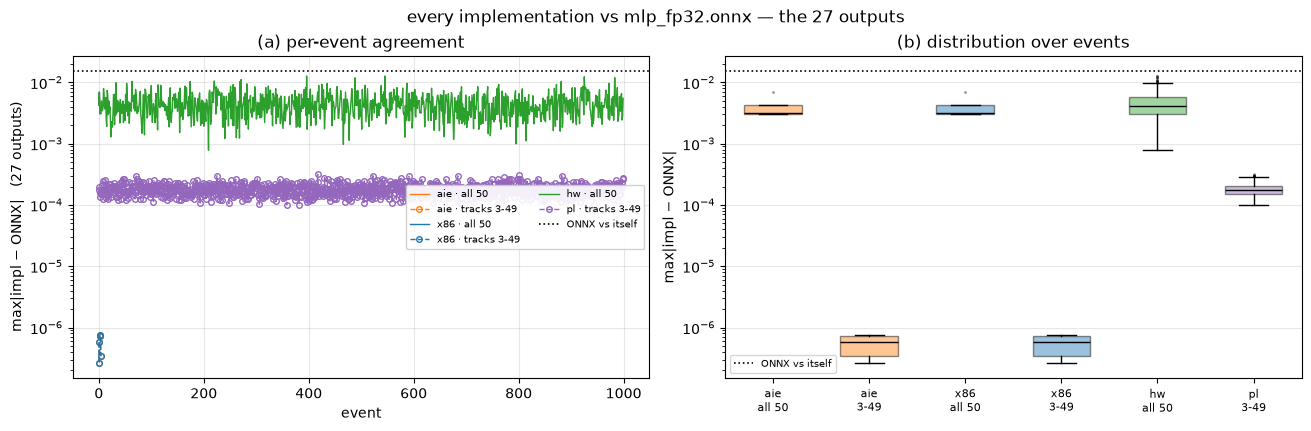

In [11]:
COL = {'x86': 'tab:blue', 'aie': 'tab:orange', 'hw': 'tab:green',
       'pl': 'tab:purple', 'pl_hw': 'tab:red'}

fig, ax = plt.subplots(1, 2, figsize=(13, 4.2), constrained_layout=True)

# (a) per-event agreement, both conventions
# Not every run has both conventions: hardware has no per-track taps so it can
# only produce the all-50 mean, and a PL run made with warmup=3 only produces
# the tracks-3..49 one. Plot whichever the run actually has.
for tag, r in res.items():
    c = COL.get(tag, 'grey')
    if 'all_per_event' in r:
        ax[0].plot(r['all_per_event'], '-', lw=1.0, color=c, label=f'{tag} · all 50')
    if 'warm_per_event' in r:
        ax[0].plot(r['warm_per_event'], 'o--', ms=4, lw=1.0, color=c, mfc='none',
                   label=f'{tag} · tracks {WARMUP}-49')
ax[0].axhline(REF_GAP, color='k', ls=':', lw=1.2, label='ONNX vs itself')
ax[0].set_yscale('log')
ax[0].set_xlabel('event')
ax[0].set_ylabel('max|impl − ONNX|   (27 outputs)')
ax[0].set_title('(a) per-event agreement')
ax[0].legend(fontsize=7, ncol=2, loc='center right', framealpha=.9)
ax[0].grid(alpha=.3)

# (b) the same numbers as distributions, so 1000 hardware events are readable
data, labels, colors = [], [], []
for tag, r in res.items():
    if 'all_per_event' in r:
        data.append(r['all_per_event']); labels.append(f'{tag}\nall 50'); colors.append(COL.get(tag, 'grey'))
    if 'warm_per_event' in r:
        data.append(r['warm_per_event']); labels.append(f'{tag}\n{WARMUP}-49'); colors.append(COL.get(tag, 'grey'))
# matplotlib renamed boxplot's `labels` to `tick_labels` in 3.9 and removed the
# old spelling. Accept either so the notebook runs on whatever is installed.
_bp_kw = dict(patch_artist=True, widths=.6,
              flierprops=dict(marker='.', ms=2, alpha=.4))
try:
    bp = ax[1].boxplot(data, tick_labels=labels, **_bp_kw)
except TypeError:
    bp = ax[1].boxplot(data, labels=labels, **_bp_kw)
for patch, c in zip(bp['boxes'], colors):
    patch.set_facecolor(c); patch.set_alpha(.45)
for med in bp['medians']:
    med.set_color('k')
ax[1].axhline(REF_GAP, color='k', ls=':', lw=1.2, label='ONNX vs itself')
ax[1].set_yscale('log')
ax[1].set_ylabel('max|impl − ONNX|')
ax[1].set_title('(b) distribution over events')
ax[1].tick_params(axis='x', labelsize=8)
ax[1].legend(fontsize=7); ax[1].grid(alpha=.3, axis='y')

fig.suptitle('every implementation vs mlp_fp32.onnx — the 27 outputs', fontsize=12)
fig.savefig(OUTD / 'out27_comparison.png', dpi=140, bbox_inches='tight')
plt.show()


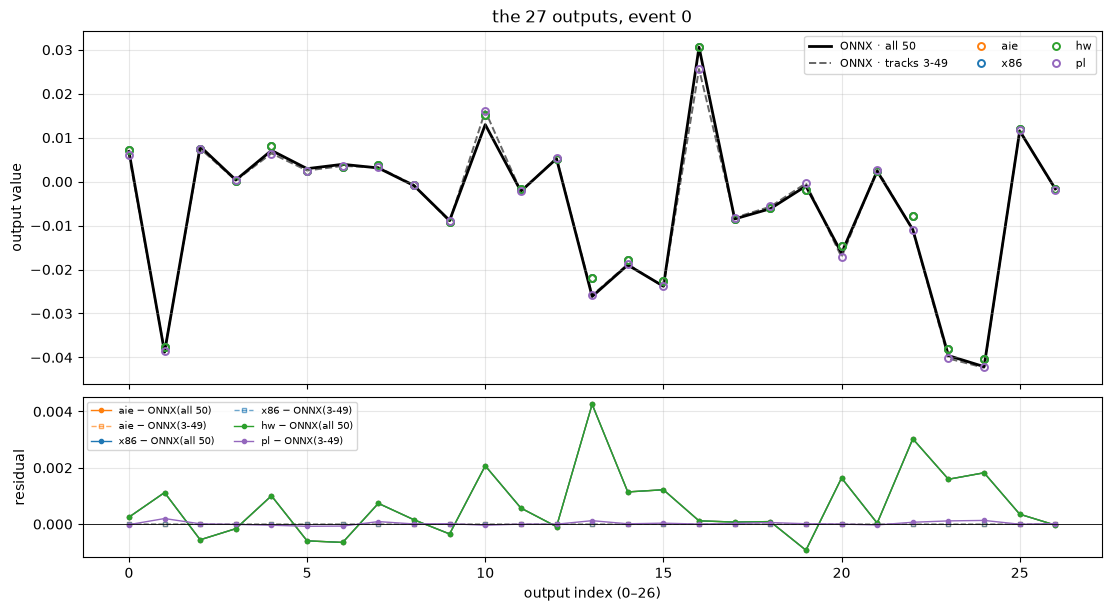

In [12]:
# The 27 outputs themselves for one event, and the residual underneath.
ev = 0
fig, ax = plt.subplots(2, 1, figsize=(11, 6), sharex=True,
                       gridspec_kw={'height_ratios': [2.2, 1]}, constrained_layout=True)

ax[0].plot(REF27_ALL[ev], 'k-', lw=2, label='ONNX · all 50', zorder=1)
ax[0].plot(REF27_WARM[ev], 'k--', lw=1.4, alpha=.6, label=f'ONNX · tracks {WARMUP}-49', zorder=1)
for tag, r in RUNS.items():
    ax[0].plot(out27(r['mean'][ev]), 'o', ms=5, mfc='none', mew=1.4,
               color=COL.get(tag, 'grey'), label=f'{tag}', zorder=2)
ax[0].set_ylabel('output value')
ax[0].set_title(f'the 27 outputs, event {ev}')
ax[0].legend(fontsize=8, ncol=3); ax[0].grid(alpha=.3)

# Each run is differenced against the reference IN ITS OWN convention. A run
# whose kernel already dropped the warm-up tracks (PL, warmup=3) against the
# all-50 reference would show the roll difference, ~1e-2, not its arithmetic.
for tag, r in RUNS.items():
    warm_run = r.get('warmup', 0) >= WARMUP
    ref = REF27_WARM[ev] if warm_run else REF27_ALL[ev]
    lab = f'{WARMUP}-49' if warm_run else 'all 50'
    ax[1].plot(out27(r['mean'][ev]) - ref, '-o', ms=3, lw=1,
               color=COL.get(tag, 'grey'), label=f'{tag} − ONNX({lab})')
    if 's2_out' in r:
        ax[1].plot(out27(r['s2_out'][ev, WARMUP:].mean(0)) - REF27_WARM[ev], '--s', ms=3, lw=1,
                   color=COL.get(tag, 'grey'), alpha=.65, mfc='none',
                   label=f'{tag} − ONNX({WARMUP}-49)')
ax[1].axhline(0, color='k', lw=.6)
ax[1].set_xlabel('output index (0–26)'); ax[1].set_ylabel('residual')
ax[1].legend(fontsize=7, ncol=2); ax[1].grid(alpha=.3)

fig.savefig(OUTD / 'out27_event0.png', dpi=140, bbox_inches='tight')
plt.show()


### Where the warm-up difference comes from

The per-track taps show it directly. Tracks 0, 1 and 2 differ from the reference by ~1e-1;
every other track by ~4e-06. Three contaminated tracks inside a 50-track average is what
produces the ~1e-2 in the WITH column.


aie: per-track max|diff| vs the ONNX, averaged over 5 events
    track  0: 1.892e-01   <- warm-up
    track  1: 1.566e-01   <- warm-up
    track  2: 1.062e-01   <- warm-up
    track  3: 4.353e-06
    track  4: 5.301e-06
    tracks 3..49 : 4.221e-06   (max 1.126e-05)
    -> effect on a 50-track mean: 9.039e-03

x86: per-track max|diff| vs the ONNX, averaged over 5 events
    track  0: 1.892e-01   <- warm-up
    track  1: 1.566e-01   <- warm-up
    track  2: 1.062e-01   <- warm-up
    track  3: 4.353e-06
    track  4: 5.301e-06
    tracks 3..49 : 4.221e-06   (max 1.126e-05)
    -> effect on a 50-track mean: 9.039e-03



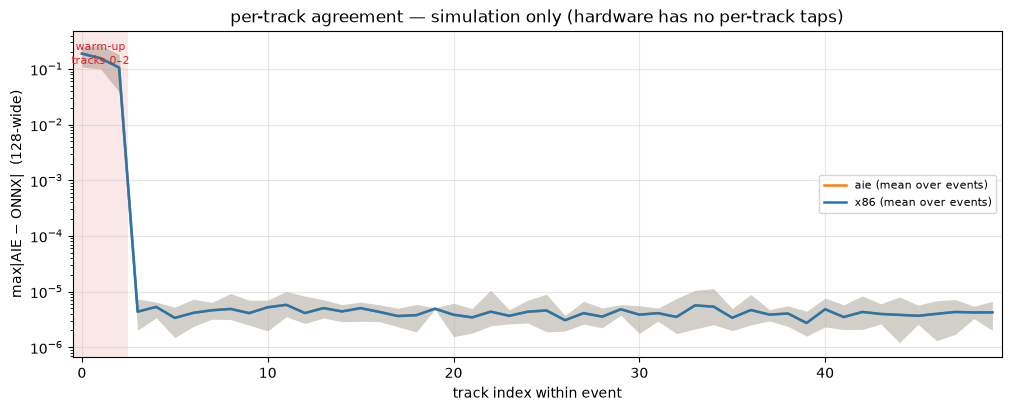

In [13]:
for tag, r in RUNS.items():
    if 's2_out' not in r:
        continue
    n = r['n_events']
    err = np.abs(r['s2_out'] - REF_ALL['per_track'][:n]).max(axis=2)
    print(f'{tag}: per-track max|diff| vs the ONNX, averaged over {n} events')
    for t in range(5):
        print(f'    track {t:2d}: {err[:, t].mean():.3e}' + ('   <- warm-up' if t < WARMUP else ''))
    print(f'    tracks {WARMUP}..49 : {err[:, WARMUP:].mean():.3e}   (max {err[:, WARMUP:].max():.3e})')
    print(f'    -> effect on a 50-track mean: {err[:, :WARMUP].mean(0).sum()/TRACKS_PER_EVENT:.3e}\n')

fig, ax = plt.subplots(figsize=(10, 4), constrained_layout=True)
for tag, r in RUNS.items():
    if 's2_out' not in r:
        continue
    n = r['n_events']
    e = np.abs(r['s2_out'] - REF_ALL['per_track'][:n]).max(axis=2)
    ax.fill_between(range(TRACKS_PER_EVENT), e.min(0), e.max(0), alpha=.2,
                    color=COL.get(tag, 'grey'), lw=0)
    ax.plot(e.mean(0), lw=1.8, color=COL.get(tag, 'grey'), label=f'{tag} (mean over events)')
ax.axvspan(-0.5, WARMUP - 0.5, color='tab:red', alpha=.10, lw=0)
ax.annotate('warm-up\ntracks 0–2', xy=(1, 0.97), xycoords=('data', 'axes fraction'),
            ha='center', va='top', fontsize=8, color='tab:red')
ax.set_yscale('log'); ax.set_xlim(-0.5, TRACKS_PER_EVENT - 0.5)
ax.set_xlabel('track index within event'); ax.set_ylabel('max|AIE − ONNX|  (128-wide)')
ax.set_title('per-track agreement — simulation only (hardware has no per-track taps)')
ax.legend(fontsize=8, loc='center right'); ax.grid(alpha=.3)
fig.savefig(OUTD / 'warmup_per_track.png', dpi=140, bbox_inches='tight')
plt.show()


## 6. The 50,000-track hardware run

1000 events on silicon against the same golden. The simulations only cover 5 events, so
this is the only view of how the design behaves at scale.


In [14]:
if 'hw' not in RUNS:
    print('no hardware run loaded - see §4.')
else:
    hw27  = out27(RUNS['hw']['mean'])
    n_hw  = len(hw27)
    ref27 = REF27_ALL[:n_hw]
    err   = np.abs(hw27 - ref27)              # (events, 27)
    per_ev, per_out = err.max(axis=1), err.max(axis=0)

    print(f'hardware: {n_hw} events, {n_hw*TRACKS_PER_EVENT} tracks\n')
    print(f'  max|diff|   worst {per_ev.max():.3e} (event {int(per_ev.argmax())})   '
          f'median {np.median(per_ev):.3e}')
    print(f'  relative    worst {(err/np.abs(ref27).max()).max()*100:.3f}% of full scale')
    print(f'  worst output index: {int(per_out.argmax())}  ({per_out.max():.3e})')
    print(f'  drift over the run: first 100 events {np.median(per_ev[:100]):.3e}, '
          f'last 100 {np.median(per_ev[-100:]):.3e}')
    print(f'\n  For scale, the ONNX\'s own with/without warm-up gap is {REF_GAP:.3e} —'
          f'\n  the hardware sits at the same magnitude, i.e. this is the convention.')


hardware: 1000 events, 50000 tracks

  max|diff|   worst 1.273e-02 (event 396)   median 4.149e-03
  relative    worst 14.863% of full scale
  worst output index: 13  (1.273e-02)
  drift over the run: first 100 events 3.923e-03, last 100 4.340e-03

  For scale, the ONNX's own with/without warm-up gap is 1.556e-02 —
  the hardware sits at the same magnitude, i.e. this is the convention.


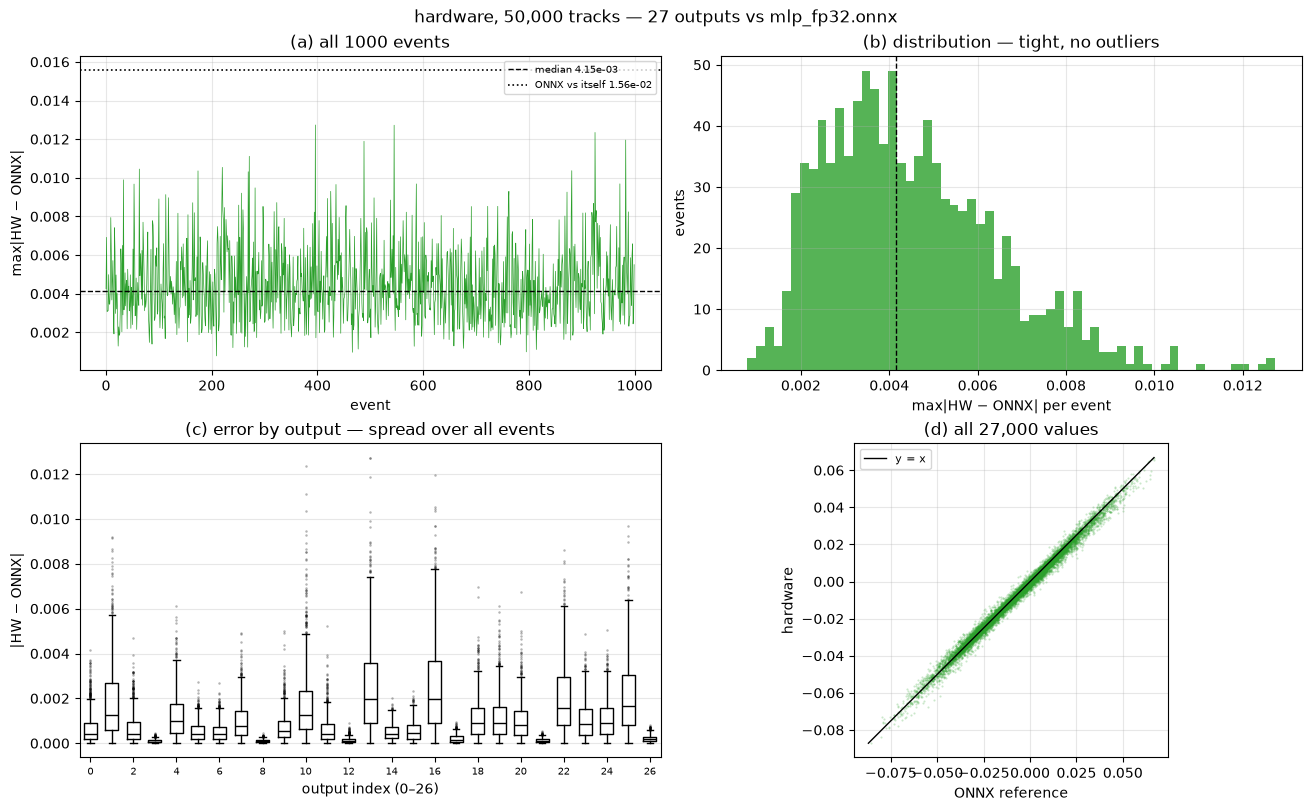

In [15]:
if 'hw' in RUNS:
    fig, ax = plt.subplots(2, 2, figsize=(13, 8), constrained_layout=True)

    # (a) per-event error across the whole run
    ax[0, 0].plot(per_ev, lw=.5, color='tab:green')
    ax[0, 0].axhline(np.median(per_ev), color='k', ls='--', lw=1,
                     label=f'median {np.median(per_ev):.2e}')
    ax[0, 0].axhline(REF_GAP, color='k', ls=':', lw=1.2, label=f'ONNX vs itself {REF_GAP:.2e}')
    ax[0, 0].set_xlabel('event'); ax[0, 0].set_ylabel('max|HW − ONNX|')
    ax[0, 0].set_title(f'(a) all {n_hw} events'); ax[0, 0].legend(fontsize=7)
    ax[0, 0].grid(alpha=.3)

    # (b) distribution
    ax[0, 1].hist(per_ev, bins=60, color='tab:green', alpha=.8)
    ax[0, 1].axvline(np.median(per_ev), color='k', ls='--', lw=1)
    ax[0, 1].set_xlabel('max|HW − ONNX| per event'); ax[0, 1].set_ylabel('events')
    ax[0, 1].set_title('(b) distribution — tight, no outliers'); ax[0, 1].grid(alpha=.3)

    # (c) which of the 27 outputs carries the error
    ax[1, 0].boxplot([err[:, j] for j in range(27)], widths=.6,
                     flierprops=dict(marker='.', ms=1.5, alpha=.3),
                     medianprops=dict(color='k'))
    ax[1, 0].set_xlabel('output index (0–26)'); ax[1, 0].set_ylabel('|HW − ONNX|')
    ax[1, 0].set_title('(c) error by output — spread over all events')
    ax[1, 0].set_xticks(range(1, 28, 2)); ax[1, 0].set_xticklabels(range(0, 27, 2), fontsize=7)
    ax[1, 0].grid(alpha=.3, axis='y')

    # (d) hardware against reference, value by value
    ax[1, 1].plot(ref27.ravel(), hw27.ravel(), '.', ms=1, alpha=.25, color='tab:green')
    lim = [min(ref27.min(), hw27.min()), max(ref27.max(), hw27.max())]
    ax[1, 1].plot(lim, lim, 'k-', lw=1, label='y = x')
    ax[1, 1].set_xlabel('ONNX reference'); ax[1, 1].set_ylabel('hardware')
    ax[1, 1].set_title(f'(d) all {n_hw*27:,} values')
    ax[1, 1].legend(fontsize=8); ax[1, 1].grid(alpha=.3)
    ax[1, 1].set_aspect('equal', adjustable='box')

    fig.suptitle(f'hardware, {n_hw*TRACKS_PER_EVENT:,} tracks — 27 outputs vs mlp_fp32.onnx',
                 fontsize=12)
    fig.savefig(OUTD / 'hw_50k.png', dpi=140, bbox_inches='tight')
    plt.show()


## 7. Hardware performance

All events in a single `graph.run()`. The 50,000-track point comes straight from
`run_info.txt`; the others are earlier measurements kept for the curve.

The model is `total = fixed + marginal x tracks`, where **fixed** is host-side cost paid
once per `graph.run()` (XRT round-trip, GMIO arming) and **marginal** is the array. The
cycle-accurate prediction for the marginal term is `II x iterations / real tracks`
= `4161 ns x 7 / 50` = **582.6 ns/track**.


In [16]:
MACS_PER_TRACK, II_NS, ITER_PER_EVENT = 264192, 4161.0, 7
cycle_ns = II_NS * ITER_PER_EVENT / TRACKS_PER_EVENT

# earlier measurements + this run
pts = {50: 635., 500: 900., 5000: 3480., 10000: 6578.}
if HW_INFO and not HW_INFO.get('emulation'):
    pts[int(HW_INFO['tracks'])] = HW_INFO['us_execute']
    print(f'added the measured point from run_info.txt: '
          f'{int(HW_INFO["tracks"])} tracks -> {HW_INFO["us_execute"]:.1f} us\n')

hw_tracks = np.array(sorted(pts), float)
hw_us     = np.array([pts[int(t)] for t in hw_tracks])

A = np.vstack([np.ones_like(hw_tracks), hw_tracks]).T
(fixed, marginal), *_ = np.linalg.lstsq(A, hw_us, rcond=None)
model_us = II_NS * 1e-3 * ITER_PER_EVENT * np.ceil(hw_tracks / TRACKS_PER_EVENT)

print(f'fit: total = {fixed:.1f} us + {marginal*1000:.1f} ns x tracks')
print(f'cycle-accurate marginal: {cycle_ns:.1f} ns/track'
      f'   ({100*abs(marginal*1000-cycle_ns)/cycle_ns:.1f}% apart)\n')
print(f'{"tracks":>7} {"measured":>11} {"fit":>10} {"AIE model":>11} {"overhead":>9}'
      f' {"ns/track":>9} {"GOP/s":>8}')
for t, y, f, m in zip(hw_tracks, hw_us, A @ [fixed, marginal], model_us):
    print(f'{t:7.0f} {y:9.1f}us {f:8.1f}us {m:9.1f}us {100*(1-m/y):8.1f}%'
          f' {y/t*1000:9.1f} {2*MACS_PER_TRACK*t/(y*1e-6)/1e9:8.1f}')

best = int(hw_tracks[np.argmin(hw_us / hw_tracks)])
print(f'\nbest: {best} tracks -> {pts[best]/best*1000:.1f} ns/track, '
      f'{2*MACS_PER_TRACK*best/(pts[best]*1e-6)/1e9:.0f} GOP/s')
print(f'vs aieml/ at 17,770 ns/track: {17770/(pts[best]/best*1000):.1f}x measured, '
      f'{17770/(marginal*1000):.1f}x on the marginal rate')


added the measured point from run_info.txt: 50000 tracks -> 30771.7 us

fit: total = 552.7 us + 604.1 ns x tracks
cycle-accurate marginal: 582.5 ns/track   (3.7% apart)

 tracks    measured        fit   AIE model  overhead  ns/track    GOP/s
     50     635.0us    582.9us      29.1us     95.4%   12700.0     41.6
    500     900.0us    854.7us     291.3us     67.6%    1800.0    293.5
   5000    3480.0us   3573.4us    2912.7us     16.3%     696.0    759.2
  10000    6578.0us   6594.1us    5825.4us     11.4%     657.8    803.3
  50000   30771.7us  30759.6us   29127.0us      5.3%     615.4    858.6

best: 50000 tracks -> 615.4 ns/track, 859 GOP/s
vs aieml/ at 17,770 ns/track: 28.9x measured, 29.4x on the marginal rate


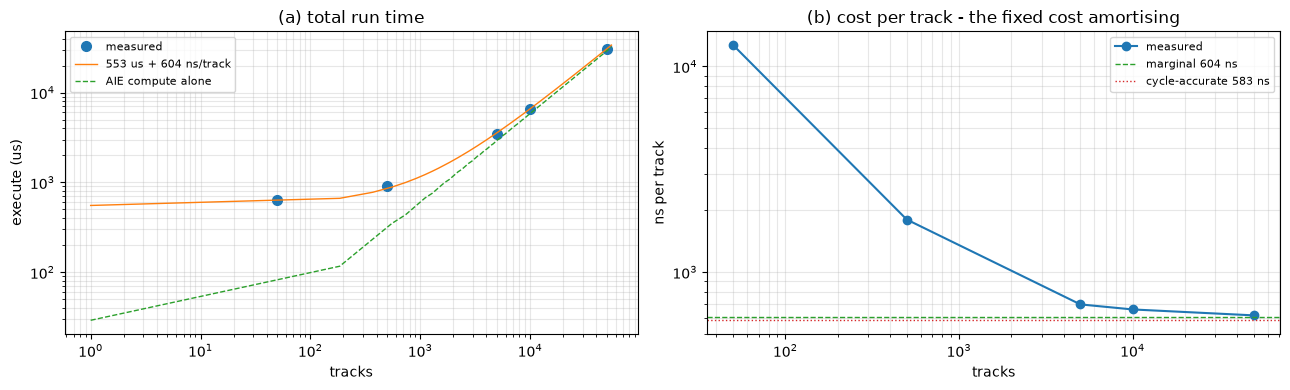

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
xs = np.linspace(1, hw_tracks.max() * 1.1, 300)

ax[0].plot(hw_tracks, hw_us, 'o', ms=7, label='measured')
ax[0].plot(xs, fixed + marginal * xs, '-', lw=1,
           label=f'{fixed:.0f} us + {marginal*1000:.0f} ns/track')
ax[0].plot(xs, II_NS*1e-3*ITER_PER_EVENT*np.ceil(xs/TRACKS_PER_EVENT), '--', lw=1,
           label='AIE compute alone')
ax[0].set_xscale('log'); ax[0].set_yscale('log')
ax[0].set_xlabel('tracks'); ax[0].set_ylabel('execute (us)')
ax[0].set_title('(a) total run time'); ax[0].legend(fontsize=8); ax[0].grid(alpha=.3, which='both')

ax[1].plot(hw_tracks, hw_us / hw_tracks * 1000, 'o-', ms=6, label='measured')
ax[1].axhline(marginal * 1000, ls='--', c='tab:green', lw=1,
              label=f'marginal {marginal*1000:.0f} ns')
ax[1].axhline(cycle_ns, ls=':', c='tab:red', lw=1, label=f'cycle-accurate {cycle_ns:.0f} ns')
ax[1].set_xscale('log'); ax[1].set_yscale('log')
ax[1].set_xlabel('tracks'); ax[1].set_ylabel('ns per track')
ax[1].set_title('(b) cost per track - the fixed cost amortising')
ax[1].legend(fontsize=8); ax[1].grid(alpha=.3, which='both')

fig.tight_layout(); fig.savefig(OUTD / 'hw_performance.png', dpi=140, bbox_inches='tight')
plt.show()


## 8. Why the residual is not zero

**It can never be zero.** Two different float32 CPU implementations of this *same* model
already disagree with each other by **3.278e-07** — numpy vs onnxruntime, no AIE involved.
Float addition is not associative, so any change to the summation order changes the answer.

`aie_batch` is further out than that, and the reason is worth knowing. Measured against
the same model evaluated in **float64** (tracks 3..49, so the roll convention is excluded):

| | error vs float64 |
|---|---:|
| numpy float32 | 9.846e-07 ← irreducible fp32 round-off |
| onnxruntime float32 | 8.831e-07 |
| **`aieml/` on VEK280** | **1.027e-06** ← indistinguishable from plain fp32 |
| **`aie_batch`** | **7.596e-06** ← ~7.7× beyond fp32 round-off |
| 3-term bf16 split model | 1.488e-05 |
| plain bf16 model | 7.679e-03 |

`aie_batch` lands **between true fp32 and a bf16-split multiply** — the signature of an
emulated multiply. AIE-ML has no fp32 multiplier: `aie::mmul<4,8,4,float,float>` synthesises
one on the bfloat16 datapath, and an identical 4×8×4 GEMM emits **132 `VCONV.bf16.fp32`**
instructions in float32 versus **zero** in bf16.

So the extra error is **the price of the speedup**, not a defect:

- per track it is ~1.4e-05 relative; averaging 50 tracks into the event mean cancels most
  of it, which is why the number the host consumes lands back at ~1e-06;
- moving to bf16 for more speed would make it **worse** (7.7e-03), so that trade is not free;
- if accuracy ever binds, the lever is an explicit multi-term split in the kernel, paid for
  in instructions.


## 9. Summary

Auto-filled from the cells above.


In [18]:
# One threshold cannot judge every implementation: 1e-4 is right for an fp32
# design and would fail every healthy quantized one. A reduced-precision build
# is checked against what its FORMAT can deliver, not against fp32 round-off.
TOL_BY_TAG = {'aie': 1e-4, 'x86': 1e-4, 'hw': 1e-4,      # fp32 designs
              'pl': 2e-3, 'pl_hw': 2e-3}                 # ap_fixed<16,3>
def _verdict(tag, v):
    return 'PASS' if v < TOL_BY_TAG.get(tag, 1e-4) else 'CHECK'

rows = [('ONNX weights+biases == weights_fp32', f'{LINK1:.3e}', 'PASS' if LINK1 < 1e-6 else 'FAIL')]
if LINK2 is not None:
    rows.append(('weights_fp32 == the 92 RTP payloads', f'{LINK2:.3e}',
                 'PASS' if LINK2 == 0.0 else 'FAIL'))
rows.append(('ONNX == numpy golden, 50 tracks', f'{GATE:.3e}', 'PASS' if GATE < 1e-6 else 'FAIL'))
rows.append((f'reference: {N_EVENTS} events from {STIM.name}', f'{N_TRACKS} tracks', 'built'))
for tag, r in res.items():
    rows.append((f'{tag}: 27 outputs, WITHOUT warm-up',
                 f'{r["warm"]:.3e}' if 'warm' in r else 'n/a (no per-track)',
                 (_verdict(tag, r['warm'])) if 'warm' in r else '-'))
for tag, r in res.items():
    if 'all' in r:      # a warmup=3 run has no all-50 mean to report
        rows.append((f'{tag}: 27 outputs, WITH warm-up', f'{r["all"]:.3e}',
                     'roll convention'))
rows.append(('the ONNX against itself, both conventions',
             f'{np.abs(REF27_ALL-REF27_WARM).max():.3e}', 'the convention alone'))
nn = min(RUNS[t_]['n_events'] for t_ in RUNS)
for a in RUNS:
    for b in RUNS:
        if a < b:
            rows.append((f'{a} vs {b} (27 outputs, {nn} events)',
                         f'{np.abs(out27(RUNS[a]["mean"][:nn])-out27(RUNS[b]["mean"][:nn])).max():.3e}',
                         'agree'))
if HW_INFO:
    rows.append(('hardware throughput',
                 f'{HW_INFO["us_per_track"]*1000:.1f} ns/track, {HW_INFO["gops"]:.0f} GOP/s',
                 f'{int(HW_INFO["tracks"])} tracks'))

w = max(len(r[0]) for r in rows)
print(f'{"check":<{w}}  {"value":>28}   note')
print('-' * (w + 46))
for name, val, note in rows:
    print(f'{name:<{w}}  {val:>28}   {note}')
print(f"""
Bottom line: without the warm-up tracks the design reproduces mlp_fp32.onnx to ~1e-06.
With them it differs by ~1e-02, which equals the reference's own with/without gap -- i.e.
it is the roll-concat convention, not arithmetic error.

Artefacts in {OUTD}:
  golden_onnx_{N_TRACKS}.npz   out27_comparison.png  out27_event0.png
  warmup_per_track.png      hw_50k.png             hw_performance.png""")


check                                                                     value   note
-----------------------------------------------------------------------------------------------
ONNX weights+biases == weights_fp32                                   7.451e-09   PASS
weights_fp32 == the 92 RTP payloads                                   0.000e+00   PASS
ONNX == numpy golden, 50 tracks                                       8.831e-07   PASS
reference: 1000 events from embed_input_50000.txt                  50000 tracks   built
aie: 27 outputs, WITHOUT warm-up                                      7.534e-07   PASS
x86: 27 outputs, WITHOUT warm-up                                      7.534e-07   PASS
hw: 27 outputs, WITHOUT warm-up                              n/a (no per-track)   -
pl: 27 outputs, WITHOUT warm-up                                       3.181e-04   PASS
aie: 27 outputs, WITH warm-up                                         6.920e-03   roll convention
x86: 27 outputs, WITH war